In [1]:
!pip install tensorflow==2.15.0

# Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = "/content/drive/My Drive/Second year Research/ecg_dataset.npz"


In [4]:
import numpy as np

loaded = np.load(path)
X = loaded["x"]
y = loaded["y"]

print(X.shape, y.shape)


(15075, 5000, 12) (15075,)


## Split Data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
print("X_test shape:", X_test.shape)
print("Y_test shape:", y_test.shape)
print("Label counts:", np.unique(y_test, return_counts=True))

X_test shape: (3015, 5000, 12)
Y_test shape: (3015,)
Label counts: (array([0, 1], dtype=int32), array([1814, 1201]))


In [7]:
!pip install imblearn

## Under-sampling

In [8]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train.reshape((X_train.shape[0], -1)), y_train)
X_rus = X_rus.reshape((-1, 5000, 12))

print("After Under-Sampling:", np.bincount(y_rus))

After Under-Sampling: [4805 4805]


## Over-sampling

In [9]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train.reshape((X_train.shape[0], -1)), y_train)
X_ros = X_ros.reshape((-1, 5000, 12))  # Reshape back to original

print("After Over-Sampling:", np.bincount(y_ros))

After Over-Sampling: [7255 7255]


# Model Creation

## Imports

In [10]:
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.models import clone_model

## Classifier

In [11]:
def build_classifier_from_features(n_features):
    inputs = Input(shape=(n_features,))
    outputs = layers.Dense(1, activation='sigmoid')(inputs)
    model = Model(inputs, outputs, name="ClassificationHead")
    return model

## Common Configurations

In [12]:
import tensorflow as tf

from tensorflow.keras.metrics import Metric, Precision, Recall, AUC

class F1ScoreBinary(Metric):

    def __init__(self, name='f1', threshold=0.5, **kwargs):

        super().__init__(name=name, **kwargs)

        self.threshold = threshold

        self.tp = self.add_weight(name='tp', initializer='zeros')

        self.fp = self.add_weight(name='fp', initializer='zeros')

        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)

        y_true = tf.cast(y_true, tf.float32)

        tp = tf.reduce_sum(y_true * y_pred)

        fp = tf.reduce_sum((1 - y_true) * y_pred)

        fn = tf.reduce_sum(y_true * (1 - y_pred))

        self.tp.assign_add(tp)

        self.fp.assign_add(fp)

        self.fn.assign_add(fn)

    def result(self):

        return 2 * self.tp / (2 * self.tp + self.fp + self.fn + 1e-8)

    def reset_state(self):

        self.tp.assign(0)

        self.fp.assign(0)

        self.fn.assign(0)


In [13]:
from tensorflow.keras.metrics import Precision, Recall, AUC
f1 = F1ScoreBinary(threshold=0.5)

compile_config = {
    'optimizer': 'adam',
    'loss': 'binary_crossentropy',
    'metrics': ['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc'), f1]
}

## n-32 Model

In [14]:
def build_cnn_model_feature_extractor_32(input_shape=(5000, 12)): # (time_steps, channels)
    model = models.Sequential([
        layers.Conv1D(32, 5, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
    ])

    return model

In [15]:
feature_model_32 = build_cnn_model_feature_extractor_32((5000, 12))
classifier_32 = build_classifier_from_features(32)
full_model_32 = models.Sequential([feature_model_32, classifier_32])

full_model_32.compile(**compile_config)

### Clone Model

In [16]:
full_model_32_weight = clone_model(full_model_32)
full_model_32_weight.set_weights(full_model_32.get_weights())
full_model_32_weight.compile(**compile_config)

# Clone for oversampling
full_model_32_ros = clone_model(full_model_32)
full_model_32_ros.set_weights(full_model_32.get_weights())
full_model_32_ros.compile(**compile_config)

# Clone for undersampling
full_model_32_rus = clone_model(full_model_32)
full_model_32_rus.set_weights(full_model_32.get_weights())
full_model_32_rus.compile(**compile_config)

## n-64 Model

In [17]:
def build_cnn_model_feature_extractor_64(input_shape=(5000, 12)): # (time_steps, channels)
    model = models.Sequential([
        layers.Conv1D(64, 5, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 5, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
    ])

    return model

In [18]:
feature_model_64 = build_cnn_model_feature_extractor_64((5000, 12))
classifier_64 = build_classifier_from_features(64)
full_model_64 = models.Sequential([feature_model_64, classifier_64])

full_model_64.compile(**compile_config)

### clone model

In [19]:
full_model_64_weight = clone_model(full_model_64)
full_model_64_weight.set_weights(full_model_64.get_weights())
full_model_64_weight.compile(**compile_config)

# Clone for oversampling
full_model_64_ros = clone_model(full_model_64)
full_model_64_ros.set_weights(full_model_64.get_weights())
full_model_64_ros.compile(**compile_config)

# Clone for undersampling
full_model_64_rus = clone_model(full_model_64)
full_model_64_rus.set_weights(full_model_64.get_weights())
full_model_64_rus.compile(**compile_config)

## n-128 Model

In [20]:
def build_cnn_model_feature_extractor_128(input_shape=(5000, 12)): # (time_steps, channels)
    model = models.Sequential([
        layers.Conv1D(128, 5, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(256, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.Conv1D(256, 5, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
    ])

    return model

In [21]:
feature_model_128 = build_cnn_model_feature_extractor_128((5000, 12))
classifier_128 = build_classifier_from_features(128)
full_model_128 = models.Sequential([feature_model_128, classifier_128])

full_model_128.compile(**compile_config)

### Clone Model

In [22]:
full_model_128_weight = clone_model(full_model_128)
full_model_128_weight.set_weights(full_model_128.get_weights())
full_model_128_weight.compile(**compile_config)

# Clone for oversampling
full_model_128_ros = clone_model(full_model_128)
full_model_128_ros.set_weights(full_model_128.get_weights())
full_model_128_ros.compile(**compile_config)

# Clone for undersampling
full_model_128_rus = clone_model(full_model_128)
full_model_128_rus.set_weights(full_model_128.get_weights())
full_model_128_rus.compile(**compile_config)

## n-256 Model

In [23]:
def build_cnn_model_feature_extractor_256(input_shape=(5000, 12)): # (time_steps, channels)
    model = models.Sequential([
        layers.Conv1D(256, 5, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(512, 5, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.Conv1D(512, 5, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(256, activation='relu'),
    ])

    return model

In [24]:
feature_model_256 = build_cnn_model_feature_extractor_256((5000, 12))
classifier_256 = build_classifier_from_features(256)
full_model_256 = models.Sequential([feature_model_256, classifier_256])

full_model_256.compile(**compile_config)

### Clone Model

In [25]:
full_model_256_weight = clone_model(full_model_256)
full_model_256_weight.set_weights(full_model_256.get_weights())
full_model_256_weight.compile(**compile_config)

# Clone for oversampling
full_model_256_ros = clone_model(full_model_256)
full_model_256_ros.set_weights(full_model_256.get_weights())
full_model_256_ros.compile(**compile_config)

# Clone for undersampling
full_model_256_rus = clone_model(full_model_256)
full_model_256_rus.set_weights(full_model_256.get_weights())
full_model_256_rus.compile(**compile_config)

# Train Model

## Callbacks

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
        monitor='val_f1',       #
        patience=3,               # Stop after 3 epochs with no improvement
        restore_best_weights=True,
        mode="max"
    )

def get_checkpoint(model_name):
    checkpoint = ModelCheckpoint(
        model_name,                      # filename to save
        monitor="val_f1",          # what to track
        mode="max",                      # because higher val_accuracy is better
        save_best_only=True,             # only save if it's the best so far
        verbose=1                        # prints info when it saves
    )
    return checkpoint



## Base Model

### n-32 Model

In [ ]:
full_model_32.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("1DCNN_FeatureExtractor_32.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3901 - accuracy: 0.8267 - precision: 0.8480 - recall: 0.6884 - auc: 0.8916 - f1: 0.7599
Epoch 1: val_f1 improved from -inf to 0.81589, saving model to 1DCNN_FeatureExtractor_32.h5
377/377 [==============================] - 40s 102ms/step - loss: 0.3901 - accuracy: 0.8267 - precision: 0.8480 - recall: 0.6884 - auc: 0.8916 - f1: 0.7599 - val_loss: 0.3473 - val_accuracy: 0.8524 - val_precision: 0.8109 - val_recall: 0.8210 - val_auc: 0.9208 - val_f1: 0.8159
Epoch 2/100
  1/377 [..............................] - ETA: 35s - loss: 0.1662 - accuracy: 0.9688 - precision: 0.9474 - recall: 1.0000 - auc: 1.0000 - f1: 0.9730

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


377/377 [==============================] - ETA: 0s - loss: 0.3249 - accuracy: 0.8643 - precision: 0.8813 - recall: 0.7621 - auc: 0.9231 - f1: 0.8174
Epoch 2: val_f1 did not improve from 0.81589
377/377 [==============================] - 37s 98ms/step - loss: 0.3249 - accuracy: 0.8643 - precision: 0.8813 - recall: 0.7621 - auc: 0.9231 - f1: 0.8174 - val_loss: 0.3890 - val_accuracy: 0.8362 - val_precision: 0.7440 - val_recall: 0.8976 - val_auc: 0.9285 - val_f1: 0.8136
Epoch 3/100
377/377 [==============================] - ETA: 0s - loss: 0.3069 - accuracy: 0.8735 - precision: 0.8905 - recall: 0.7784 - auc: 0.9312 - f1: 0.8306
Epoch 3: val_f1 improved from 0.81589 to 0.83288, saving model to 1DCNN_FeatureExtractor_32.h5
377/377 [==============================] - 37s 99ms/step - loss: 0.3069 - accuracy: 0.8735 - precision: 0.8905 - recall: 0.7784 - auc: 0.9312 - f1: 0.8306 - val_loss: 0.3051 - val_accuracy: 0.8773 - val_precision: 0.9102 - val_recall: 0.7677 - val_auc: 0.9359 - val_f1: 0.8

### n-64 Model

In [ ]:
full_model_64.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("1DCNN_FeatureExtractor_64.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3820 - accuracy: 0.8339 - precision: 0.8537 - recall: 0.7358 - auc: 0.9083 - f1: 0.7904
Epoch 1: val_f1 improved from -inf to 0.75605, saving model to 1DCNN_FeatureExtractor_64.h5
377/377 [==============================] - 100s 262ms/step - loss: 0.3820 - accuracy: 0.8339 - precision: 0.8537 - recall: 0.7358 - auc: 0.9083 - f1: 0.7904 - val_loss: 0.3799 - val_accuracy: 0.8395 - val_precision: 0.9579 - val_recall: 0.6245 - val_auc: 0.9267 - val_f1: 0.7560
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3190 - accuracy: 0.8687 - precision: 0.8828 - recall: 0.7729 - auc: 0.9259 - f1: 0.8242
Epoch 2: val_f1 improved from 0.75605 to 0.83874, saving model to 1DCNN_FeatureExtractor_64.h5
377/377 [==============================] - 97s 258ms/step - loss: 0.3190 - accuracy: 0.8687 - precision: 0.8828 - recall: 0.7729 - auc: 0.9259 - f1: 0.8242 - val_loss: 0.3326 - val_accuracy: 0.8680 - val_precisio

### n-128 Model

In [ ]:
full_model_128.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("1DCNN_FeatureExtractor_128.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3799 - accuracy: 0.8348 - precision: 0.8594 - recall: 0.7348 - auc: 0.9095 - f1: 0.7922
Epoch 1: val_f1 improved from -inf to 0.74975, saving model to 1DCNN_FeatureExtractor_128.h5
377/377 [==============================] - 314s 830ms/step - loss: 0.3799 - accuracy: 0.8348 - precision: 0.8594 - recall: 0.7348 - auc: 0.9095 - f1: 0.7922 - val_loss: 0.3590 - val_accuracy: 0.8355 - val_precision: 0.9513 - val_recall: 0.6187 - val_auc: 0.9315 - val_f1: 0.7497
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3153 - accuracy: 0.8703 - precision: 0.8846 - recall: 0.7757 - auc: 0.9286 - f1: 0.8266
Epoch 2: val_f1 improved from 0.74975 to 0.83408, saving model to 1DCNN_FeatureExtractor_128.h5
377/377 [==============================] - 315s 837ms/step - loss: 0.3153 - accuracy: 0.8703 - precision: 0.8846 - recall: 0.7757 - auc: 0.9286 - f1: 0.8266 - val_loss: 0.3150 - val_accuracy: 0.8779 - val_preci

### n-256 Model

In [ ]:
full_model_256.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("1DCNN_FeatureExtractor_256.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3777 - accuracy: 0.8388 - precision: 0.8658 - recall: 0.7348 - auc: 0.9094 - f1: 0.7949
Epoch 1: val_f1 improved from -inf to 0.81829, saving model to 1DCNN_FeatureExtractor_256.h5
377/377 [==============================] - 1088s 3s/step - loss: 0.3777 - accuracy: 0.8388 - precision: 0.8658 - recall: 0.7348 - auc: 0.9094 - f1: 0.7949 - val_loss: 0.3960 - val_accuracy: 0.8418 - val_precision: 0.7542 - val_recall: 0.8943 - val_auc: 0.9265 - val_f1: 0.8183
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3145 - accuracy: 0.8684 - precision: 0.8836 - recall: 0.7713 - auc: 0.9271 - f1: 0.8236
Epoch 2: val_f1 improved from 0.81829 to 0.82982, saving model to 1DCNN_FeatureExtractor_256.h5
377/377 [==============================] - 1050s 3s/step - loss: 0.3145 - accuracy: 0.8684 - precision: 0.8836 - recall: 0.7713 - auc: 0.9271 - f1: 0.8236 - val_loss: 0.3053 - val_accuracy: 0.8743 - val_precision

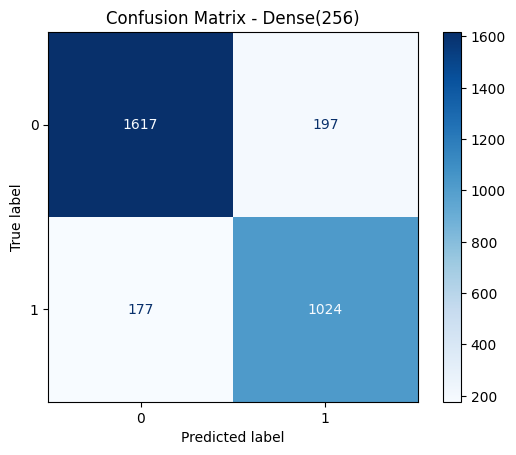

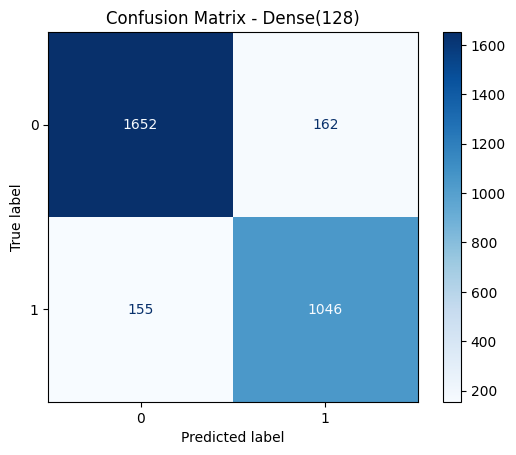

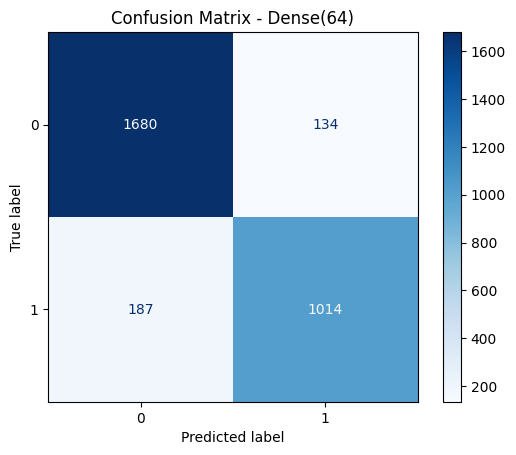

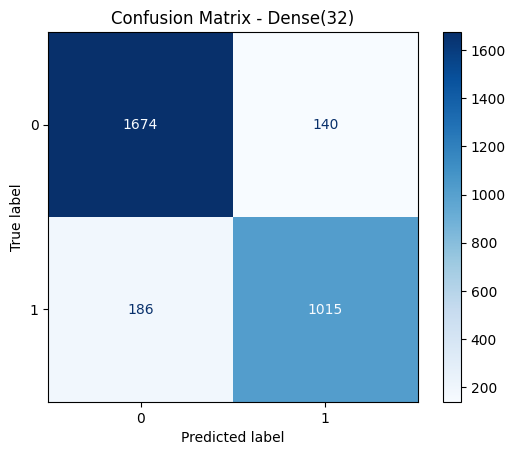

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load your trained models with custom metric
model_32 = tf.keras.models.load_model("1DCNN_FeatureExtractor_32.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_64 = tf.keras.models.load_model("1DCNN_FeatureExtractor_64.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_128 = tf.keras.models.load_model("1DCNN_FeatureExtractor_128.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_256 = tf.keras.models.load_model("1DCNN_FeatureExtractor_256.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})

# Define function to plot confusion matrix
def plot_conf_matrix(model, X_val, y_val, title):
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Generate and plot confusion matrices
plot_conf_matrix(model_256, X_test, y_test, "Confusion Matrix - Dense(256)")
plot_conf_matrix(model_128, X_test, y_test, "Confusion Matrix - Dense(128)")
plot_conf_matrix(model_64,  X_test, y_test, "Confusion Matrix - Dense(64)")
plot_conf_matrix(model_32,  X_test, y_test, "Confusion Matrix - Dense(32)")



## Class Weights

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.8311509303928325, 1: 1.254942767950052}


### n-32 Model

In [ ]:
full_model_32_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_1DCNN_FeatureExtractor_32.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.4062 - accuracy: 0.8227 - precision: 0.8033 - recall: 0.7562 - auc: 0.8944 - f1: 0.7791
Epoch 1: val_f1 improved from -inf to 0.79228, saving model to Weighted_1DCNN_FeatureExtractor_32.h5
377/377 [==============================] - 41s 104ms/step - loss: 0.4062 - accuracy: 0.8227 - precision: 0.8033 - recall: 0.7562 - auc: 0.8944 - f1: 0.7791 - val_loss: 0.4242 - val_accuracy: 0.8143 - val_precision: 0.7144 - val_recall: 0.8893 - val_auc: 0.9217 - val_f1: 0.7923
Epoch 2/100
  1/377 [..............................] - ETA: 39s - loss: 0.4475 - accuracy: 0.7812 - precision: 0.6923 - recall: 0.7500 - auc: 0.8896 - f1: 0.7200

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


377/377 [==============================] - ETA: 0s - loss: 0.3396 - accuracy: 0.8635 - precision: 0.8418 - recall: 0.8096 - auc: 0.9234 - f1: 0.8254
Epoch 2: val_f1 improved from 0.79228 to 0.83150, saving model to Weighted_1DCNN_FeatureExtractor_32.h5
377/377 [==============================] - 38s 101ms/step - loss: 0.3396 - accuracy: 0.8635 - precision: 0.8418 - recall: 0.8096 - auc: 0.9234 - f1: 0.8254 - val_loss: 0.3377 - val_accuracy: 0.8630 - val_precision: 0.8152 - val_recall: 0.8485 - val_auc: 0.9309 - val_f1: 0.8315
Epoch 3/100
377/377 [==============================] - ETA: 0s - loss: 0.3206 - accuracy: 0.8728 - precision: 0.8553 - recall: 0.8194 - auc: 0.9317 - f1: 0.8369
Epoch 3: val_f1 did not improve from 0.83150
377/377 [==============================] - 38s 100ms/step - loss: 0.3206 - accuracy: 0.8728 - precision: 0.8553 - recall: 0.8194 - auc: 0.9317 - f1: 0.8369 - val_loss: 0.3669 - val_accuracy: 0.8507 - val_precision: 0.7684 - val_recall: 0.8951 - val_auc: 0.9343 - 

### n-64 Model

In [ ]:
full_model_64_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_1DCNN_FeatureExtractor_64.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.4020 - accuracy: 0.8224 - precision: 0.7812 - recall: 0.7985 - auc: 0.9039 - f1: 0.7898
Epoch 1: val_f1 improved from -inf to 0.81886, saving model to Weighted_1DCNN_FeatureExtractor_64.h5
377/377 [==============================] - 106s 278ms/step - loss: 0.4020 - accuracy: 0.8224 - precision: 0.7812 - recall: 0.7985 - auc: 0.9039 - f1: 0.7898 - val_loss: 0.3247 - val_accuracy: 0.8637 - val_precision: 0.8699 - val_recall: 0.7735 - val_auc: 0.9267 - val_f1: 0.8189
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3396 - accuracy: 0.8609 - precision: 0.8360 - recall: 0.8096 - auc: 0.9240 - f1: 0.8226
Epoch 2: val_f1 did not improve from 0.81886
377/377 [==============================] - 103s 273ms/step - loss: 0.3396 - accuracy: 0.8609 - precision: 0.8360 - recall: 0.8096 - auc: 0.9240 - f1: 0.8226 - val_loss: 0.3203 - val_accuracy: 0.8663 - val_precision: 0.9300 - val_recall: 0.7186 - val_auc

### n-128 Model

In [ ]:
full_model_128_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_1DCNN_FeatureExtractor_128.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3921 - accuracy: 0.8351 - precision: 0.8155 - recall: 0.7912 - auc: 0.9093 - f1: 0.8032
Epoch 1: val_f1 improved from -inf to 0.82182, saving model to Weighted_1DCNN_FeatureExtractor_128.h5
377/377 [==============================] - 323s 853ms/step - loss: 0.3921 - accuracy: 0.8351 - precision: 0.8155 - recall: 0.7912 - auc: 0.9093 - f1: 0.8032 - val_loss: 0.3494 - val_accuracy: 0.8537 - val_precision: 0.7983 - val_recall: 0.8468 - val_auc: 0.9283 - val_f1: 0.8218
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3333 - accuracy: 0.8685 - precision: 0.8498 - recall: 0.8137 - auc: 0.9262 - f1: 0.8314
Epoch 2: val_f1 improved from 0.82182 to 0.83924, saving model to Weighted_1DCNN_FeatureExtractor_128.h5
377/377 [==============================] - 317s 841ms/step - loss: 0.3333 - accuracy: 0.8685 - precision: 0.8498 - recall: 0.8137 - auc: 0.9262 - f1: 0.8314 - val_loss: 0.3071 - val_accuracy: 

### n-256 Model

In [ ]:
full_model_256_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_1DCNN_FeatureExtractor_256.h5")])

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 0.3851 - accuracy: 0.8339 - precision: 0.8110 - recall: 0.7950 - auc: 0.9131 - f1: 0.8029
Epoch 1: val_f1 improved from -inf to 0.80781, saving model to Weighted_1DCNN_FeatureExtractor_256.h5
377/377 [==============================] - 1065s 3s/step - loss: 0.3851 - accuracy: 0.8339 - precision: 0.8110 - recall: 0.7950 - auc: 0.9131 - f1: 0.8029 - val_loss: 0.4008 - val_accuracy: 0.8302 - val_precision: 0.7355 - val_recall: 0.8959 - val_auc: 0.9262 - val_f1: 0.8078
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 0.3340 - accuracy: 0.8678 - precision: 0.8458 - recall: 0.8173 - auc: 0.9259 - f1: 0.8313
Epoch 2: val_f1 improved from 0.80781 to 0.83594, saving model to Weighted_1DCNN_FeatureExtractor_256.h5
377/377 [==============================] - 1058s 3s/step - loss: 0.3340 - accuracy: 0.8678 - precision: 0.8458 - recall: 0.8173 - auc: 0.9259 - f1: 0.8313 - val_loss: 0.3035 - val_accuracy: 0.87

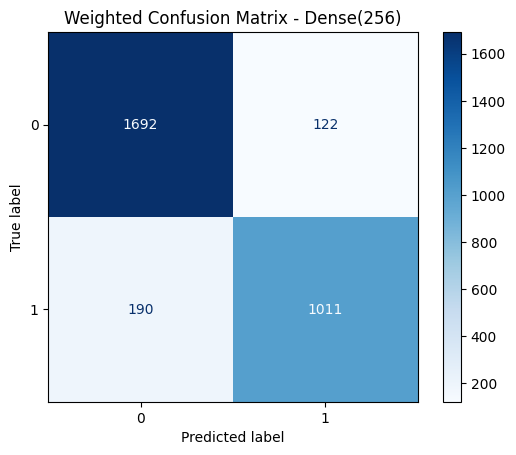

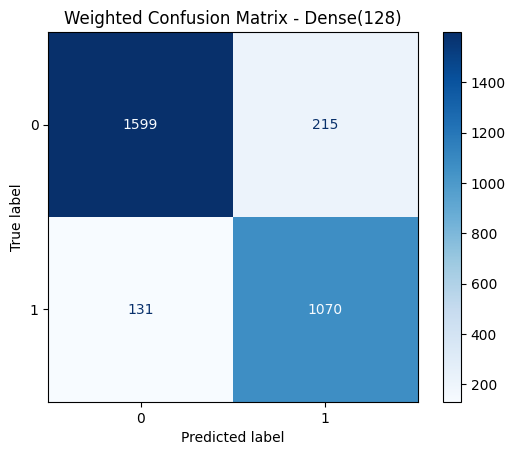

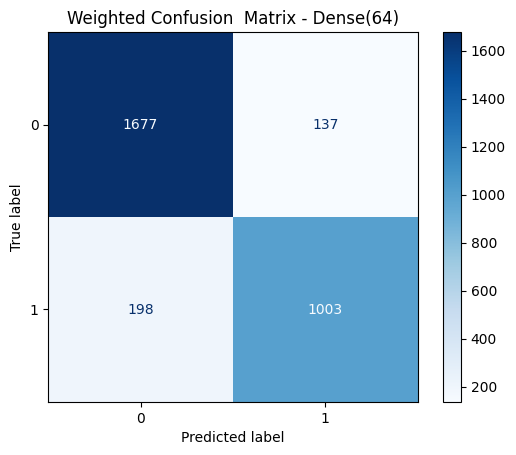

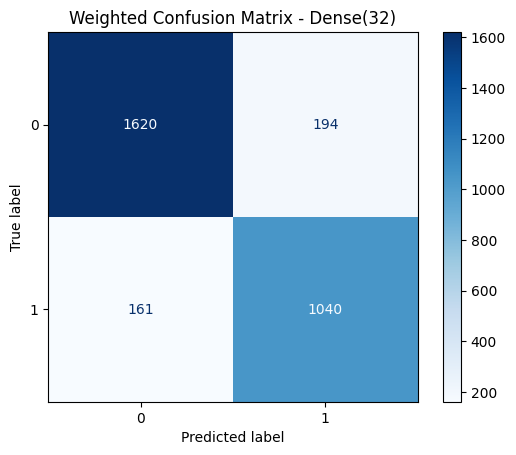

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load your trained models with custom metric
model_32 = tf.keras.models.load_model("Weighted_1DCNN_FeatureExtractor_32.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_64 = tf.keras.models.load_model("Weighted_1DCNN_FeatureExtractor_64.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_128 = tf.keras.models.load_model("Weighted_1DCNN_FeatureExtractor_128.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_256 = tf.keras.models.load_model("Weighted_1DCNN_FeatureExtractor_256.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})

# Define function to plot confusion matrix
def plot_conf_matrix(model, X_val, y_val, title):
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Generate and plot confusion matrices
plot_conf_matrix(model_256, X_test, y_test, "Weighted Confusion Matrix - Dense(256)")
plot_conf_matrix(model_128, X_test, y_test, "Weighted Confusion Matrix - Dense(128)")
plot_conf_matrix(model_64,  X_test, y_test, "Weighted Confusion  Matrix - Dense(64)")
plot_conf_matrix(model_32,  X_test, y_test, "Weighted Confusion Matrix - Dense(32)")



## Under-Sampling

### n-32 Model

In [ ]:
full_model_32_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_1DCNN_FeatureExtractor_32.h5")])

Epoch 1/100
300/301 [============================>.] - ETA: 0s - loss: 0.4100 - accuracy: 0.8158 - precision: 0.8608 - recall: 0.7780 - auc: 0.9073 - f1: 0.8173
Epoch 1: val_f1 improved from -inf to 0.81159, saving model to Under_Sampled_1DCNN_FeatureExtractor_32.h5
301/301 [==============================] - 33s 104ms/step - loss: 0.4098 - accuracy: 0.8159 - precision: 0.8608 - recall: 0.7782 - auc: 0.9074 - f1: 0.8174 - val_loss: 0.3468 - val_accuracy: 0.8534 - val_precision: 0.8314 - val_recall: 0.7927 - val_auc: 0.9196 - val_f1: 0.8116
Epoch 2/100
  1/301 [..............................] - ETA: 28s - loss: 0.3680 - accuracy: 0.8438 - precision: 0.8667 - recall: 0.8125 - auc: 0.9004 - f1: 0.8387

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


300/301 [============================>.] - ETA: 0s - loss: 0.3493 - accuracy: 0.8504 - precision: 0.8881 - recall: 0.8020 - auc: 0.9190 - f1: 0.8429
Epoch 2: val_f1 improved from 0.81159 to 0.82595, saving model to Under_Sampled_1DCNN_FeatureExtractor_32.h5
301/301 [==============================] - 30s 99ms/step - loss: 0.3490 - accuracy: 0.8506 - precision: 0.8882 - recall: 0.8021 - auc: 0.9191 - f1: 0.8430 - val_loss: 0.3192 - val_accuracy: 0.8683 - val_precision: 0.8722 - val_recall: 0.7843 - val_auc: 0.9295 - val_f1: 0.8260
Epoch 3/100
300/301 [============================>.] - ETA: 0s - loss: 0.3237 - accuracy: 0.8614 - precision: 0.8965 - recall: 0.8171 - auc: 0.9310 - f1: 0.8549
Epoch 3: val_f1 improved from 0.82595 to 0.83217, saving model to Under_Sampled_1DCNN_FeatureExtractor_32.h5
301/301 [==============================] - 30s 100ms/step - loss: 0.3240 - accuracy: 0.8612 - precision: 0.8965 - recall: 0.8166 - auc: 0.9309 - f1: 0.8547 - val_loss: 0.3133 - val_accuracy: 0.87

### n-64 Model

In [ ]:
full_model_64_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_1DCNN_FeatureExtractor_64.h5")])

Epoch 1/100
301/301 [==============================] - ETA: 0s - loss: 0.4058 - accuracy: 0.8166 - precision: 0.8631 - recall: 0.7727 - auc: 0.9077 - f1: 0.8154
Epoch 1: val_f1 improved from -inf to 0.81469, saving model to Under_Sampled_1DCNN_FeatureExtractor_64.h5
301/301 [==============================] - 85s 278ms/step - loss: 0.4058 - accuracy: 0.8166 - precision: 0.8631 - recall: 0.7727 - auc: 0.9077 - f1: 0.8154 - val_loss: 0.3462 - val_accuracy: 0.8527 - val_precision: 0.8167 - val_recall: 0.8127 - val_auc: 0.9226 - val_f1: 0.8147
Epoch 2/100
301/301 [==============================] - ETA: 0s - loss: 0.3360 - accuracy: 0.8567 - precision: 0.8937 - recall: 0.8098 - auc: 0.9253 - f1: 0.8497
Epoch 2: val_f1 improved from 0.81469 to 0.83190, saving model to Under_Sampled_1DCNN_FeatureExtractor_64.h5
301/301 [==============================] - 81s 268ms/step - loss: 0.3360 - accuracy: 0.8567 - precision: 0.8937 - recall: 0.8098 - auc: 0.9253 - f1: 0.8497 - val_loss: 0.3211 - val_accu

### n-128 Model

In [ ]:
full_model_128_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_1DCNN_FeatureExtractor_128.h5")])

Epoch 1/100
301/301 [==============================] - ETA: 0s - loss: 0.4058 - accuracy: 0.8143 - precision: 0.8418 - recall: 0.7937 - auc: 0.9063 - f1: 0.8170
Epoch 1: val_f1 improved from -inf to 0.74108, saving model to Under_Sampled_1DCNN_FeatureExtractor_128.h5
301/301 [==============================] - 257s 851ms/step - loss: 0.4058 - accuracy: 0.8143 - precision: 0.8418 - recall: 0.7937 - auc: 0.9063 - f1: 0.8170 - val_loss: 0.3891 - val_accuracy: 0.8315 - val_precision: 0.9553 - val_recall: 0.6053 - val_auc: 0.9272 - val_f1: 0.7411
Epoch 2/100
301/301 [==============================] - ETA: 0s - loss: 0.3385 - accuracy: 0.8525 - precision: 0.8873 - recall: 0.8077 - auc: 0.9244 - f1: 0.8456
Epoch 2: val_f1 improved from 0.74108 to 0.77755, saving model to Under_Sampled_1DCNN_FeatureExtractor_128.h5
301/301 [==============================] - 255s 846ms/step - loss: 0.3385 - accuracy: 0.8525 - precision: 0.8873 - recall: 0.8077 - auc: 0.9244 - f1: 0.8456 - val_loss: 0.5021 - val_

### n-256 Model

In [ ]:
full_model_256_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_1DCNN_FeatureExtractor_256.h5")])

Epoch 1/100
301/301 [==============================] - ETA: 0s - loss: 0.3983 - accuracy: 0.8173 - precision: 0.8506 - recall: 0.7909 - auc: 0.9120 - f1: 0.8197
Epoch 1: val_f1 improved from -inf to 0.81321, saving model to Under_Sampled_1DCNN_FeatureExtractor_256.h5
301/301 [==============================] - 866s 3s/step - loss: 0.3983 - accuracy: 0.8173 - precision: 0.8506 - recall: 0.7909 - auc: 0.9120 - f1: 0.8197 - val_loss: 0.3221 - val_accuracy: 0.8630 - val_precision: 0.8901 - val_recall: 0.7485 - val_auc: 0.9307 - val_f1: 0.8132
Epoch 2/100
301/301 [==============================] - ETA: 0s - loss: 0.3426 - accuracy: 0.8525 - precision: 0.8864 - recall: 0.8087 - auc: 0.9223 - f1: 0.8458
Epoch 2: val_f1 did not improve from 0.81321
301/301 [==============================] - 862s 3s/step - loss: 0.3426 - accuracy: 0.8525 - precision: 0.8864 - recall: 0.8087 - auc: 0.9223 - f1: 0.8458 - val_loss: 0.4127 - val_accuracy: 0.8299 - val_precision: 0.7334 - val_recall: 0.9001 - val_auc

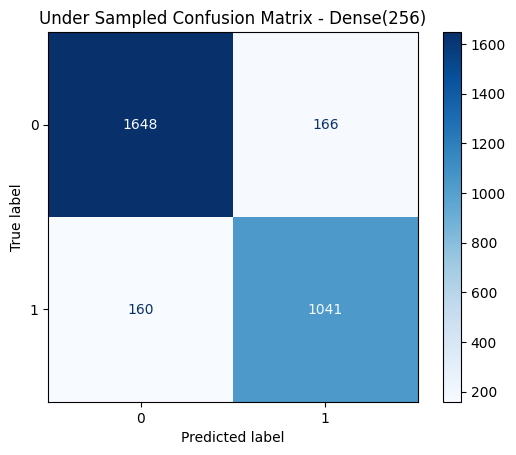

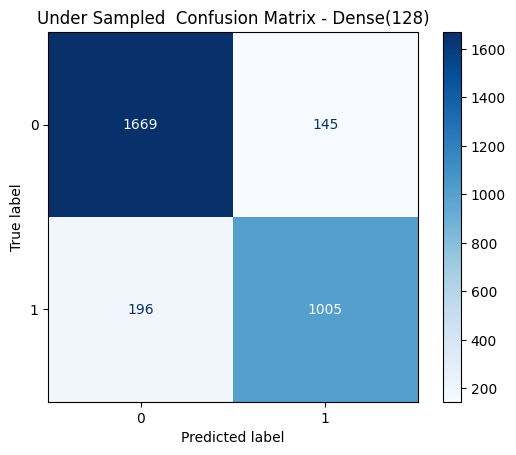

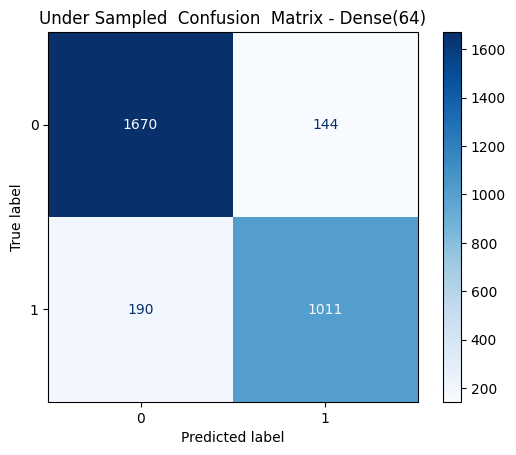

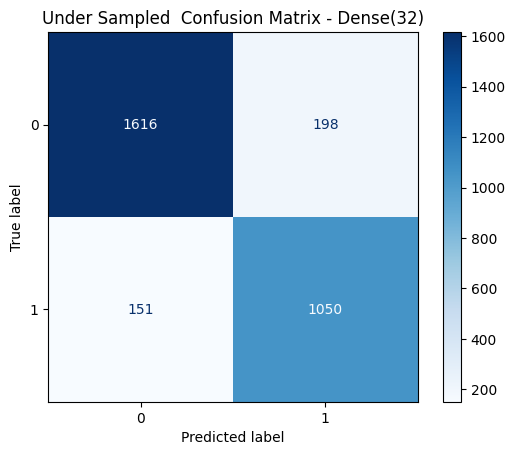

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load your trained models with custom metric
model_32 = tf.keras.models.load_model("Under_Sampled_1DCNN_FeatureExtractor_32.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_64 = tf.keras.models.load_model("Under_Sampled_1DCNN_FeatureExtractor_64.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_128 = tf.keras.models.load_model("Under_Sampled_1DCNN_FeatureExtractor_128.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_256 = tf.keras.models.load_model("Under_Sampled_1DCNN_FeatureExtractor_256.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})

# Define function to plot confusion matrix
def plot_conf_matrix(model, X_val, y_val, title):
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Generate and plot confusion matrices
plot_conf_matrix(model_256, X_test, y_test, "Under Sampled Confusion Matrix - Dense(256)")
plot_conf_matrix(model_128, X_test, y_test, "Under Sampled  Confusion Matrix - Dense(128)")
plot_conf_matrix(model_64,  X_test, y_test, "Under Sampled  Confusion  Matrix - Dense(64)")
plot_conf_matrix(model_32,  X_test, y_test, "Under Sampled  Confusion Matrix - Dense(32)")



## Over-Sampling

### n-32 Model

In [27]:
full_model_32_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_1DCNN_FeatureExtractor_32.h5")])

Epoch 1/100
454/454 [==============================] - ETA: 0s - loss: 0.3869 - accuracy: 0.8263 - precision: 0.8463 - recall: 0.7974 - auc: 0.9024 - f1: 0.8211
Epoch 1: val_f1 improved from -inf to 0.82230, saving model to Over_Sampled_1DCNN_FeatureExtractor_32.h5
454/454 [==============================] - 53s 114ms/step - loss: 0.3869 - accuracy: 0.8263 - precision: 0.8463 - recall: 0.7974 - auc: 0.9024 - f1: 0.8211 - val_loss: 0.3476 - val_accuracy: 0.8594 - val_precision: 0.8278 - val_recall: 0.8168 - val_auc: 0.9260 - val_f1: 0.8223
Epoch 2/100
  1/454 [..............................] - ETA: 45s - loss: 0.4683 - accuracy: 0.8125 - precision: 1.0000 - recall: 0.6471 - auc: 0.8529 - f1: 0.7857

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


453/454 [============================>.] - ETA: 0s - loss: 0.3338 - accuracy: 0.8550 - precision: 0.8874 - recall: 0.8132 - auc: 0.9265 - f1: 0.8486
Epoch 2: val_f1 did not improve from 0.82230
454/454 [==============================] - 49s 108ms/step - loss: 0.3337 - accuracy: 0.8551 - precision: 0.8875 - recall: 0.8132 - auc: 0.9266 - f1: 0.8487 - val_loss: 0.6118 - val_accuracy: 0.7191 - val_precision: 0.5911 - val_recall: 0.9559 - val_auc: 0.9313 - val_f1: 0.7305
Epoch 3/100
453/454 [============================>.] - ETA: 0s - loss: 0.3142 - accuracy: 0.8662 - precision: 0.8980 - recall: 0.8261 - auc: 0.9351 - f1: 0.8606
Epoch 3: val_f1 improved from 0.82230 to 0.84351, saving model to Over_Sampled_1DCNN_FeatureExtractor_32.h5
454/454 [==============================] - 49s 108ms/step - loss: 0.3144 - accuracy: 0.8660 - precision: 0.8979 - recall: 0.8259 - auc: 0.9350 - f1: 0.8604 - val_loss: 0.3009 - val_accuracy: 0.8793 - val_precision: 0.8720 - val_recall: 0.8168 - val_auc: 0.938

### n-64 Model

In [28]:
full_model_64_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_1DCNN_FeatureExtractor_64.h5")])

Epoch 1/100
454/454 [==============================] - ETA: 0s - loss: 0.3803 - accuracy: 0.8312 - precision: 0.8569 - recall: 0.8031 - auc: 0.9138 - f1: 0.8291
Epoch 1: val_f1 improved from -inf to 0.81917, saving model to Over_Sampled_1DCNN_FeatureExtractor_64.h5
454/454 [==============================] - 137s 298ms/step - loss: 0.3803 - accuracy: 0.8312 - precision: 0.8569 - recall: 0.8031 - auc: 0.9138 - f1: 0.8291 - val_loss: 0.3381 - val_accuracy: 0.8561 - val_precision: 0.8198 - val_recall: 0.8185 - val_auc: 0.9262 - val_f1: 0.8192
Epoch 2/100
454/454 [==============================] - ETA: 0s - loss: 0.3245 - accuracy: 0.8632 - precision: 0.8949 - recall: 0.8230 - auc: 0.9308 - f1: 0.8575
Epoch 2: val_f1 improved from 0.81917 to 0.84132, saving model to Over_Sampled_1DCNN_FeatureExtractor_64.h5
454/454 [==============================] - 127s 279ms/step - loss: 0.3245 - accuracy: 0.8632 - precision: 0.8949 - recall: 0.8230 - auc: 0.9308 - f1: 0.8575 - val_loss: 0.3077 - val_accu

### n-128 Model

In [29]:
full_model_128_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_1DCNN_FeatureExtractor_128.h5")])

Epoch 1/100
454/454 [==============================] - ETA: 0s - loss: 0.3760 - accuracy: 0.8297 - precision: 0.8451 - recall: 0.8056 - auc: 0.9124 - f1: 0.8248
Epoch 1: val_f1 improved from -inf to 0.83203, saving model to Over_Sampled_1DCNN_FeatureExtractor_128.h5
454/454 [==============================] - 407s 893ms/step - loss: 0.3760 - accuracy: 0.8297 - precision: 0.8451 - recall: 0.8056 - auc: 0.9124 - f1: 0.8248 - val_loss: 0.3201 - val_accuracy: 0.8720 - val_precision: 0.8715 - val_recall: 0.7960 - val_auc: 0.9316 - val_f1: 0.8320
Epoch 2/100
454/454 [==============================] - ETA: 0s - loss: 0.3232 - accuracy: 0.8629 - precision: 0.8942 - recall: 0.8233 - auc: 0.9314 - f1: 0.8573
Epoch 2: val_f1 improved from 0.83203 to 0.83484, saving model to Over_Sampled_1DCNN_FeatureExtractor_128.h5
454/454 [==============================] - 392s 863ms/step - loss: 0.3232 - accuracy: 0.8629 - precision: 0.8942 - recall: 0.8233 - auc: 0.9314 - f1: 0.8573 - val_loss: 0.3340 - val_ac

### n-256 Model

In [30]:
full_model_256_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_1DCNN_FeatureExtractor_256.h5")])

Epoch 1/100
454/454 [==============================] - ETA: 0s - loss: 0.3982 - accuracy: 0.8198 - precision: 0.8439 - recall: 0.7994 - auc: 0.9064 - f1: 0.8211
Epoch 1: val_f1 improved from -inf to 0.81987, saving model to Over_Sampled_1DCNN_FeatureExtractor_256.h5
454/454 [==============================] - 1391s 3s/step - loss: 0.3982 - accuracy: 0.8198 - precision: 0.8439 - recall: 0.7994 - auc: 0.9064 - f1: 0.8211 - val_loss: 0.3505 - val_accuracy: 0.8521 - val_precision: 0.7961 - val_recall: 0.8451 - val_auc: 0.9267 - val_f1: 0.8199
Epoch 2/100
454/454 [==============================] - ETA: 0s - loss: 0.3297 - accuracy: 0.8598 - precision: 0.8942 - recall: 0.8163 - auc: 0.9285 - f1: 0.8534
Epoch 2: val_f1 improved from 0.81987 to 0.82398, saving model to Over_Sampled_1DCNN_FeatureExtractor_256.h5
454/454 [==============================] - 1384s 3s/step - loss: 0.3297 - accuracy: 0.8598 - precision: 0.8942 - recall: 0.8163 - auc: 0.9285 - f1: 0.8534 - val_loss: 0.3470 - val_accura

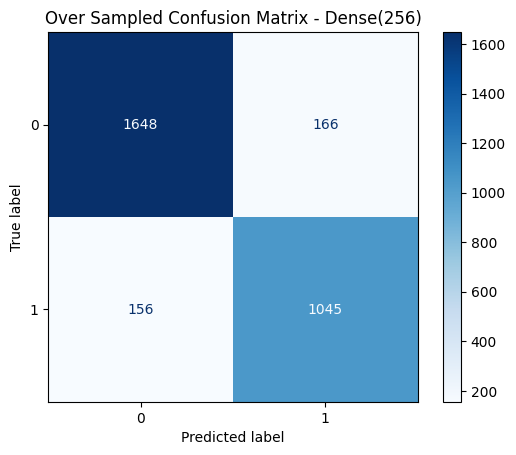

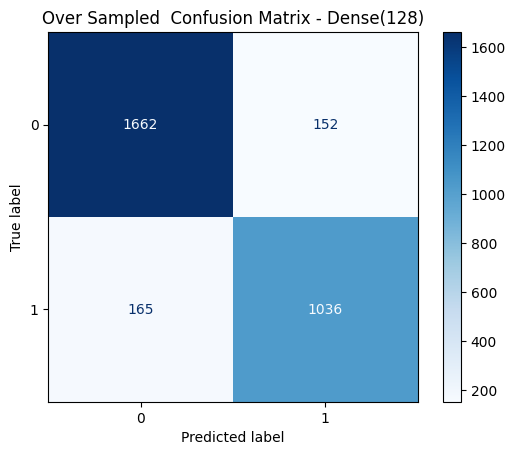

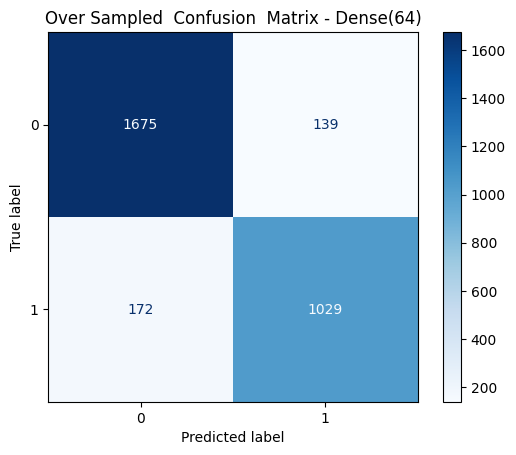

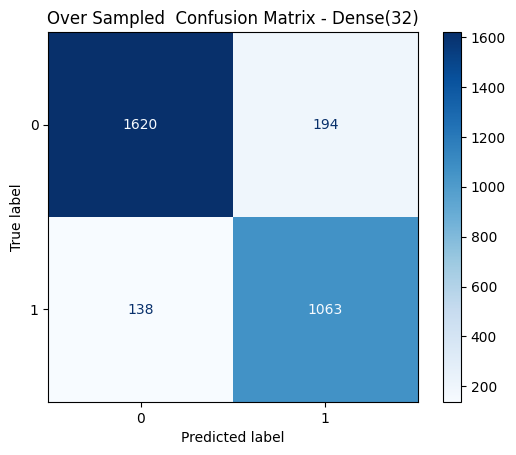

In [31]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load your trained models with custom metric
model_32 = tf.keras.models.load_model("Over_Sampled_1DCNN_FeatureExtractor_32.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_64 = tf.keras.models.load_model("Over_Sampled_1DCNN_FeatureExtractor_64.h5",
                                      custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_128 = tf.keras.models.load_model("Over_Sampled_1DCNN_FeatureExtractor_128.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})
model_256 = tf.keras.models.load_model("Over_Sampled_1DCNN_FeatureExtractor_256.h5",
                                       custom_objects={"F1ScoreBinary": F1ScoreBinary})

# Define function to plot confusion matrix
def plot_conf_matrix(model, X_val, y_val, title):
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Generate and plot confusion matrices
plot_conf_matrix(model_256, X_test, y_test, "Over Sampled Confusion Matrix - Dense(256)")
plot_conf_matrix(model_128, X_test, y_test, "Over Sampled  Confusion Matrix - Dense(128)")
plot_conf_matrix(model_64,  X_test, y_test, "Over Sampled  Confusion  Matrix - Dense(64)")
plot_conf_matrix(model_32,  X_test, y_test, "Over Sampled  Confusion Matrix - Dense(32)")

